In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass

%config InlineBackend.figure_format = 'retina'

In [2]:
# utilities
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def row_normalize(matrix, eps=1e-12):
    row_sums = matrix.sum(axis=1, keepdims=True)
    return matrix / (eps + row_sums)

In [3]:
# Experimental function
def build_exp_graph():
    n_node = 11
    community = np.array([0, 0, 0, 0, 0, 
                          1, 1, 1, 1, 1, 1])
    
    node_degree = np.array([4, 3, 3, 4, 4, 
                            4, 3, 3, 4, 4, 4])
    
    edges = [
        # community 1
        (0, 1), (0, 2), (0, 3), (0, 10),
        (1, 0), (1, 3), (1, 4),
        (2, 0), (2, 3), (2, 4),
        (3, 0), (3, 1), (3, 2), (3, 4),
        (4, 1), (4, 2), (4, 3), (4, 5),

        # community 2   
        (5, 4), (5, 6), (5, 8), (5, 9),
        (6, 5), (6, 7), (6, 9),
        (7, 6), (7, 8), (7, 10),
        (8, 5), (8, 7), (8, 9), (8, 10),
        (9, 5), (9, 6), (9, 8), (9, 10),
        (10, 0), (10, 7), (10, 8), (10, 9)
    ]

    adjacency = np.zeros((n_node, n_node))
    for i, j in edges:
        adjacency[i, j] = True

    return adjacency, community, node_degree

def random_walk(adjacency, length, rng, start_node=-1):
    n_nodes = adjacency.shape[0]

    if start_node >= 0:
        current_node = start_node
    else:
        current_node = rng.integers(n_nodes)
    seq = [current_node]

    for _ in range(length - 1):
        neighbors = np.flatnonzero(adjacency[current_node])
        current_node = rng.choice(neighbors)
        seq.append(current_node)
    
    return np.array(seq, dtype=int)

def make_trials(adjacency,
                community,
                rng,
                n_block=5,
                n_tone_per_trial=10):
    '''
    adjacency: np.array [n_node, n_node]
    community: np.array [n_node, 1]
    '''

    n_nodes = adjacency.shape[0]

    # remove possible self-transitions
    adjacency = adjacency.copy()
    np.fill_diagonal(adjacency, 0.0)

    # emulate all posible direct final transitions
    cue, target = np.where(
        ~np.eye(n_nodes, dtype=bool)
    )

    pairs = np.column_stack([cue, target])
    is_legal = adjacency[cue, target] > 0
    is_within = (community[cue] == community[target])

    within_legal = pairs[is_legal & is_within]       # 36
    between_legal = pairs[is_legal & ~is_within]     # 4
    within_illegal = pairs[~is_legal & is_within]    # 14
    between_illegal = pairs[~is_legal & ~is_within]  # 26 out of 56

    # each block - n(legal) == n(illegal)
    n_legal = within_legal.shape[0] + between_legal.shape[0]
    n_between_illegal = n_legal - within_illegal.shape[0]

    # construct each block
    block_tables = []
    for iBlc in range(n_block):
        selected_between_illegal = (
            between_illegal[
                rng.choice(between_illegal.shape[0], 
                           size=n_between_illegal,
                           replace=False)
            ]
        )

        final_pairs = np.vstack(
            [
                within_legal,
                between_legal,
                within_illegal,
                selected_between_illegal
            ]
        )

        # randomize trial order within the block
        final_pairs = final_pairs[rng.permutation(final_pairs.shape[0])]
        final_targets = final_pairs[:, 1]
        final_cue = final_pairs[:, 0]

        # generate first 9 tones & flip
        n_trial_per_block = final_pairs.shape[0]
        prefix = np.empty((n_trial_per_block, n_tone_per_trial-1), dtype=int)
        for iRow in range(n_trial_per_block):
            reversed = random_walk(adjacency, 
                                   length=n_tone_per_trial-1, 
                                   rng=rng, 
                                   start_node=final_cue[iRow])
            prefix[iRow, :] = reversed[::-1]

        sequence = np.column_stack([prefix, final_targets])
        legal = adjacency[final_cue, final_targets] > 0
        within = community[final_cue] == community[final_targets]

        membership_label = np.where(within, 'within', 'between')
        legal_label = np.where(legal, 'legal', 'illegal')
        trial_type = np.char.add(membership_label, '_')
        trial_type = np.char.add(trial_type, legal_label)

        regularity = np.where(within == legal, 'regular', 'irregular')

        block_tbl = pd.DataFrame(
            {
                "block": iBlc,
                "trial_in_block": np.arange(n_trial_per_block),
                "cue": final_cue,
                "target": final_targets,
                'legal': legal,
                "within": within,
                "trial_type": trial_type,
                "regularity": regularity
            }
        )
        block_tbl['sequence'] = list(sequence)
        block_tables.append(block_tbl)
    
    trials = pd.concat(block_tables, ignore_index=True)


    return trials




In [4]:
# model
@dataclass
class ModelParameters:

    beta: float = 0.06
    lr: float = 1.0
    reset_current_activity: bool = True

    decision_gain: float = 20.0
    criterion_offset: float = 0.0

    @property
    def trace_decay(self):
        return np.exp(-self.beta)
    
class HebbianSequenceModel:
    def __init__(self, n_nodes, params):
        self.n_nodes = n_nodes
        self.params = params

        self.W = np.zeros(
            (n_nodes, n_nodes),
            dtype=float
        )

        self.exposure_seq = None
    
    def learn_exposure(self, sequence):
        sequence = np.asarray(sequence, dtype=int)

        if sequence.ndim != 1:
            raise ValueError("Exposure sequence must be a 1-d array.")
        
        # store exposure sequence
        self.exposure_seq = sequence.copy()

        trace = np.zeros(self.n_nodes, dtype=float)

        trace[sequence[0]] = 1
        for current in sequence[1:]:
            # trace decay exponentially
            trace *= self.params.trace_decay

            # strengthening of association is positively associated with trace strength
            self.W[:,current] += (self.params.lr * trace)

            # activate the current tone
            if self.params.reset_current_activity:
                trace[current] = 1.0
            else:
                trace[current] += 1.0
        
        return self
    
    def association_matrix(self, normalize=True):
        '''
        1. remove diagnal of weight matrix
        2. row normalization
        '''

        matrix = self.W.copy()
        np.fill_diagonal(matrix, 0.0)

        if normalize:
            matrix = row_normalize(matrix)
        
        return matrix
    
    def get_familiarity(self, cue, target, normalize=True):
        matrix = self.association_matrix(normalize=normalize)
        return float(matrix[cue, target])
    
    def decision_evidence(self, cue, target):
        familiarity = self.get_familiarity(cue, 
                                           target, 
                                           normalize=True)
        uniform_baseline = 1.0 / (self.n_nodes - 1)
        evidence = familiarity - uniform_baseline - self.params.criterion_offset

        return evidence
    
    def choice_probability(self, cue, target):
        evidence = self.decision_evidence(cue, target)
        p_yes = sigmoid(evidence * self.params.decision_gain)

        return float(p_yes)
    
    def simulate_choice(self, cue, target, rng):
        p_yes = self.choice_probability(cue, target)
        yes = int(rng.random() < p_yes)
        return{'p_yes': p_yes,
                'yes': yes,
        }
    
    def copy(self):
        copied_model = HebbianSequenceModel(
            n_nodes=self.n_nodes,
            params=self.params,
        )

        copied_model.W = self.W.copy()

        if self.exposure_seq is not None:
            copied_model.exposure_seq = (
                self.exposure_seq.copy()
            )

        return copied_model
    
    def consolidation():
        pass

def evaluate_model(model, 
                   trials, 
                   adjacency):
    results = trials.copy()

    cues = results['cue'].to_numpy(dtype=int)
    targets = results['target'].to_numpy(dtype=int)

    # associative familiarity
    ass_matrix = model.association_matrix(normalize=True)
    familiarity = ass_matrix[cues, targets]

    # decision readout
    baseline_uniform = 1 / (model.n_nodes - 1)
    decision_evidence = familiarity - baseline_uniform - model.params.criterion_offset
    p_yes = sigmoid(model.params.decision_gain * decision_evidence)

    # expected accuracy
    expected_acc = np.where(results['legal'].to_numpy(dtype=bool), p_yes, 1-p_yes)
    
    results['familiarity'] = familiarity
    results['decision_evidence'] = decision_evidence
    results['p_yes'] = p_yes
    results['exp_acc'] = expected_acc
    
    return results


In [5]:
def Exp_simulation_day1(n_subj,
                        exposure_length,
                        beta=0.06,
                        seed=1):
    
    adjacency, community, node_degree = build_exp_graph()

    subject_seeds = np.random.SeedSequence(seed).spawn(n_subj)

    all_data = []
    models = []
    for iSubj, subj_seed in enumerate(subject_seeds):
        # set seeds for each subject
        exposure_seed, trial_seed = subj_seed.spawn(2)
        exposure_rng = np.random.default_rng(exposure_seed)
        trial_rng = np.random.default_rng(trial_seed)

        exposure_seq = random_walk(adjacency, 
                                   exposure_length, 
                                   exposure_rng)
        
        # train day1 model
        params = ModelParameters(beta=beta)
        mdl_day1 = HebbianSequenceModel(
            n_nodes=adjacency.shape[0],
            params=params
        )
        mdl_day1.learn_exposure(exposure_seq)

        # generate behaviral test trials
        trials = make_trials(adjacency, 
                             community, 
                             trial_rng)
        subject_data = evaluate_model(mdl_day1, 
                                      trials, 
                                      adjacency)
        subject_data.insert(0, 'subj', iSubj)
        subject_data.insert(1, 'session', 'Day1')

        all_data.append(subject_data)
        models.append(mdl_day1)
    
    all_data = pd.concat(all_data,
                         ignore_index=True)
    
    return all_data, models

### Simulation Start

In [6]:
time_ms = 6 * 60 * 1000
iti_ms = 80
tone_ms = 100
exposure_length = time_ms // (iti_ms + tone_ms)

day1_data, day1_model = Exp_simulation_day1(n_subj=29, 
                                            exposure_length=exposure_length)


print(day1_data.shape)
day1_data.head()

(11600, 15)


,subj,session,block,trial_in_block,cue,target,legal,within,trial_type,regularity,sequence,familiarity,decision_evidence,p_yes,exp_acc
0,0,Day1,0,0,10,9,True,True,within_legal,regular,"[8, 7, 6, 9, 8, 7, 6, 9, 10, 9]",0.142424,0.042424,0.700249,0.700249
1,0,Day1,0,1,0,6,False,False,between_illegal,regular,"[0, 10, 9, 5, 4, 2, 0, 1, 0, 6]",0.060116,-0.039884,0.310523,0.689477
2,0,Day1,0,2,1,3,True,True,within_legal,regular,"[8, 5, 8, 9, 10, 0, 3, 0, 1, 3]",0.141226,0.041226,0.695193,0.695193
3,0,Day1,0,3,2,10,False,False,between_illegal,regular,"[4, 1, 0, 3, 1, 3, 1, 0, 2, 10]",0.080245,-0.019755,0.402488,0.597512
4,0,Day1,0,4,0,10,True,False,between_legal,irregular,"[5, 4, 1, 4, 3, 2, 3, 2, 0, 10]",0.105671,0.005671,0.528323,0.528323


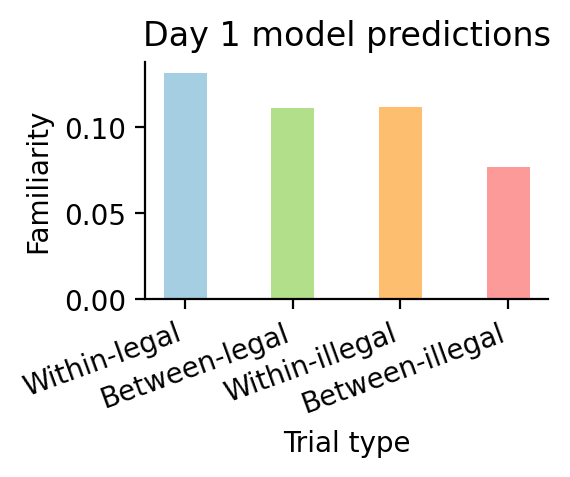

In [23]:
trial_order = ['within_legal',
               'between_legal',
               'within_illegal',
               'between_illegal']
palette_whole = sns.color_palette('Paired', 12)
bar_colors = [palette_whole[i] for i in [0, 2, 6, 4]]

avg_within_subj = (
    day1_data.groupby(['subj', 'trial_type'], as_index=False)
    .agg(familiarity = ('familiarity', 'mean'))
)

dat4plot = (
    avg_within_subj.groupby('trial_type', as_index=False)
    .agg(mean_dat = ('familiarity', 'mean'),
         sd_dat = ('familiarity', 'std'),
         n_subj = ('familiarity', 'count'))
)
dat4plot['se_dat'] = dat4plot['sd_dat'] / np.sqrt(dat4plot['n_subj'])
dat4plot['trial_type'] = pd.Categorical(
    dat4plot['trial_type'],
    categories=trial_order,
    ordered=True
)

dat4plot = dat4plot.sort_values('trial_type').reset_index(drop=True)

# plot figures
fig, ax = plt.subplots(figsize=(3, 2.5))
x=np.arange(len(dat4plot))
ax.bar(
    x, 
    dat4plot['mean_dat'],
    # yerr=dat4plot['se_dat'],
    width=0.4,
    color=bar_colors,
    capsize=5,
    error_kw={
        "elinewidth": 1.5,
        "capthick": 1.5
    },
)
ax.set_xticks(x)
ax.set_xticklabels(
    [
        "Within-legal",
        "Between-legal",
        "Within-illegal",
        "Between-illegal",
    ],
    rotation=20,
    ha='right'
)

ax.set_xlabel("Trial type")
ax.set_ylabel("Familiarity")
ax.set_title("Day 1 model predictions")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()